In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d

import tqdm as tqdm

from scipy.ndimage import gaussian_filter1d

from matplotlib.lines import Line2D



In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    '100*theta_s': 1.041783,
    #"h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params)
lcdm.set({
    "output": "mPk",
    "P_k_max_h/Mpc": 10.0,
    "z_pk": 0.0,
})
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
# rho_nu_lcdm = bg_lcdm['(.)rho_ncdm[0]']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")

kk = np.logspace(-4,0,1000) # k in h/Mpc
h = lcdm.h() # get reduced Hubble for conversions to 1/Mpc
Pk_lcdm = [] # P(k) in (Mpc/h)**3
for k in kk:
    Pk_lcdm.append(lcdm.pk(k*h,0.)*h**3) # function .pk(k,z)


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### Constants

num_of_gigayears = 0.1
tau_acc = num_of_gigayears*3600*24*365*1e9 # convert to seconds
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e15
m_wdm = 1e-10 # smaller, to make it relativistic
omega_dm = 0.1201075
# kappa = 12
a_t = 0.01
eta = np.sqrt(2)-1 #sqrt(2)-1 gives P = m_dcdm, so DCDM->DR with "one relativistic decay product" -- if I wanted to have more realistic DCDM->2DR P=m_dcdm/2 I'd have to double number density

kappa = 1 #[0.01, 0.1, 0.5, 1.0] #[0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
a_rec = 1/(1+1100) # scale factor at recombination, approximation to adjust omega_cdm 
k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])

gauges = ['newtonian', 'synchronous']


In [ ]:
### Run CLASS for DCDM->DR model for comparison

#DCDM_CLASS = {}
bgDCDM, pbDCDM, clDCDM = {}, {}, {}
Pk_dcdm = {}

for gauge in tqdm.tqdm(gauges):
    DCDM_CLASS = Class()
    DCDM_CLASS.set(base_params)
    DCDM_CLASS.set({    'output': 'tCl, pCl, lCl, mPk',
                        'l_max_scalars': 2500,
                        'k_output_values': k_values_CLASS,
                        'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1), # Adjust omega to keep theta_s fixed
                        # accDM params
                        #'vary_Gamma_wdm': 'no',                     # Don't use the more general formulation, but the decay formulation for a direct comparison with the DCDM->DR case
                        'kappa_mon':      kappa,               # Acceleration parameter
                        'a_t_mon':        a_t,                 # Roughly speaking the scale factor at which the acceleration happens
                        'f_mon':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
                        'gauge':          gauge,               # Gauge choice for the perturbations
                        })
    DCDM_CLASS.compute()
    bgDCDM[gauge] = DCDM_CLASS.get_background()
    pbDCDM[gauge] = DCDM_CLASS.get_perturbations()
    clDCDM[gauge] = DCDM_CLASS.raw_cl(2500)
    
    ## MATTER POWER SPECTRUM
    Pk_dcdm['DCDM->DR', gauge] = [] # P(k) in (Mpc/h)**3
    h = DCDM_CLASS.h() # get reduced Hubble for conversions to 1/Mpc
    for k in kk:
        Pk_dcdm['DCDM->DR', gauge].append(DCDM_CLASS.pk(k*h,0.)*h**3) # function .pk(k,z)

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# Background
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, rho_dr, p_acc = {}, {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu, p_nu = {}, {}
rho_tot, rho_crit = {}, {}

# Perturbations
delta_cdm, delta_g, delta_b, delta_nu, delta_ur = {}, {}, {}, {}, {}
delta_dcdm, delta_acc, delta_dr = {}, {}, {}

# CMB spectra
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

# Other
z_eq = {}

models = ['DCDM->DR']

for gauge in gauges:    
    for model in models:
        if model == 'DCDM->DR':
            bg = bgDCDM[gauge]
            pb = pbDCDM[gauge]
            cl = clDCDM[gauge]
        else:
            raise ValueError(f"Unknown model: {model}")
        
        H[model, gauge] = bg['H [1/Mpc]']
        z[model, gauge] = bg['z']
        a[model, gauge] = 1/(1+z[model, gauge])
        
        # The usual components of the universe
        rho_g[model, gauge] = bg['(.)rho_g'] 
        rho_b[model, gauge] = bg['(.)rho_b']
        rho_cdm[model, gauge] = bg['(.)rho_cdm']
        rho_lambda[model, gauge] = bg['(.)rho_lambda']
        rho_ur[model, gauge] = bg['(.)rho_ur']
        # rho_nu[model, gauge] = bg['(.)rho_ncdm[0]']
        # p_nu[model, gauge] = bg['(.)p_ncdm[0]']

        # Energy densities of the DCDM and WDM components and the pressure of the WDM component
        rho_dcdm[model, gauge] = bg['(.)rho_mon']
        rho_acc[model, gauge] = 0 # there is no acc component in DCDM->DR model
        p_acc[model, gauge] = 0
        rho_dr[model, gauge] = bg['(.)rho_dr']

        # Total and critical energy densities
        rho_tot[model, gauge] = bg['(.)rho_tot']
        rho_crit[model, gauge] = bg['(.)rho_crit']
        
        for i in range(len(k_values)):
            scalar_data = pb['scalar'][i]  # Scalar perturbations for selected k-values
            # print(scalar_data.keys())
            a[model, gauge, k_values[i]] = scalar_data['a']
            
            # Extract perturbation quantities
            delta_cdm[model, gauge, k_values[i]] = scalar_data['delta_cdm']
            delta_g[model, gauge, k_values[i]] = scalar_data['delta_g']
            delta_b[model, gauge, k_values[i]] = scalar_data['delta_b']
            delta_ur[model, gauge, k_values[i]] = scalar_data['delta_ur']
            # delta_nu[model, gauge, k_values[i]] = scalar_data['delta_ncdm[0]']
            
            if model == 'AccDM':
                delta_dcdm[model, gauge, k_values[i]] = scalar_data['delta_dcdm']
                delta_acc[model, gauge, k_values[i]] = scalar_data['delta_ncdm[0]']
                delta_dr[model, gauge, k_values[i]] = 0
            else:
                delta_acc[model, gauge, k_values[i]] = 0 # there is no acc component in DCDM->DR model
                delta_dr[model, gauge, k_values[i]] = scalar_data['delta_dr']
                delta_dcdm[model, gauge, k_values[i]] = scalar_data['delta_mon']
            
        ### POWER SPECTRUM
        
        ll[model, gauge] = cl['ell'][2:]
        clTT[model, gauge] = cl['tt'][2:]
        clEE[model, gauge] = cl['ee'][2:]
        clTE[model, gauge] = cl['te'][2:]
        clPP[model, gauge] = cl['pp'][2:]
    

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_18108/1924408365.py:32: SyntaxWarning: invalid escape sequence '\e'
  axs[0].set_title(f'Matter Power Spectrum at z=0 for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, {gauge}, $a_t = {a_t}$', fontsize=14)


newtonian


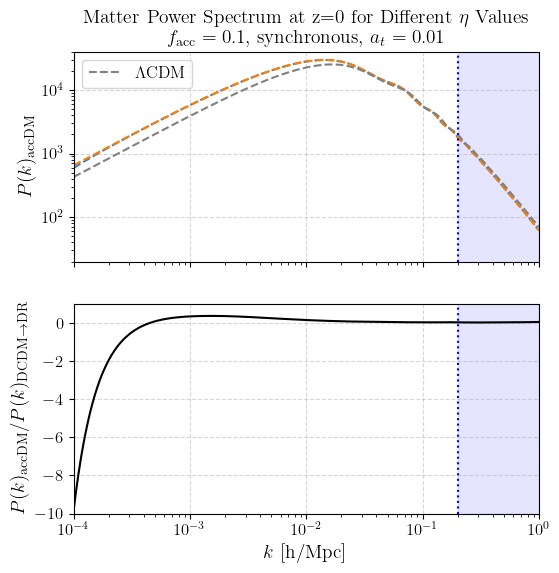

In [ ]:
### Plot Pk[eta]/Pk_LCDM for different values of eta
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

colors = colors_colorblind

for j, gauge in enumerate(gauges):
    color = colors_colorblind[j]
    axs[0].plot(kk, np.array(Pk_dcdm['DCDM->DR', gauge]), ls='--', color=color)

axs[0].plot(kk, Pk_lcdm, label=r'$\Lambda\mathrm{CDM}$', color='grey', ls='--')   

print(gauges[0])

axs[1].plot(kk, 100*(np.array(Pk_dcdm['DCDM->DR', gauges[0]])-np.array(Pk_dcdm['DCDM->DR', gauges[1]]))/np.array(Pk_dcdm['DCDM->DR', gauges[0]]), label=r'{}'.format(gauge), color='black')

for ax in axs:
    ax.axvline(x=0.2, color='blue', linestyle=':')  
    # ax.text(0.2, 3e4, r'non-linear', color='blue', fontsize=12, verticalalignment='top', rotation=90) 
    ax.set_xscale('log') 
    ax.set_xlim(1e-4, 1)  

axs[0].fill_betweenx([1e-6, 1e6], 0.2, 1, color='blue', alpha=0.1) 
axs[1].fill_betweenx([-10, 1.2], 0.2, 1, color='blue', alpha=0.1) 

axs[0].set_yscale('log')
axs[0].set_ylim(20, 4e4)
axs[1].set_yscale('linear')
axs[1].set_ylim(-10, 1)
axs[1].set_xlabel(r'$k$ [h/Mpc]')
axs[0].set_ylabel(r'$P(k)_{\mathrm{accDM}}$')
axs[1].set_ylabel(r'$P(k)_{\mathrm{accDM}}/P(k)_{\mathrm{DCDM\to DR}}$')
axs[0].set_title(f'Matter Power Spectrum at z=0 for Different $\eta$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, {gauge}, $a_t = {a_t}$', fontsize=14)
axs[0].legend()
axs[0].grid(ls='--', alpha=0.5)
axs[1].grid(ls='--', alpha=0.5)
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\k'
<>:18: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_18108/2438557971.py:18: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB TT Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
/tmp/ipykernel_18108/2438557971.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


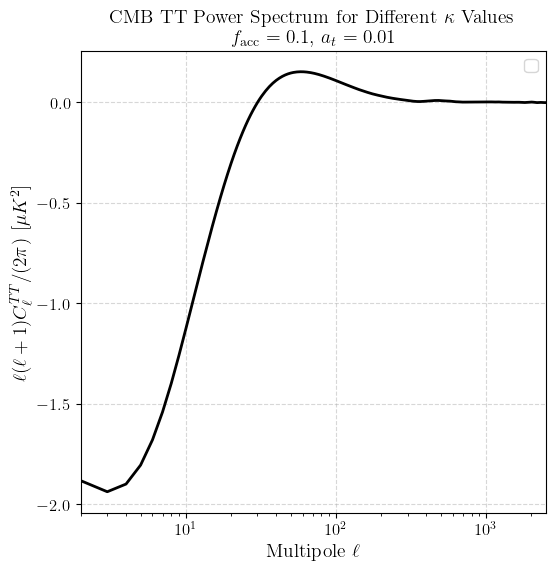

In [ ]:
### Plot TT spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ll_sync = ll['DCDM->DR', gauges[1]]
clTT_sync = ll_sync*(1+ll_sync)*clTT['DCDM->DR', gauges[1]]/(2*np.pi)
ll_new = ll['DCDM->DR', gauges[0]]
clTT_new = clTT['DCDM->DR', gauges[0]]/(2*np.pi)*ll_new*(1+ll_new)
    
ax.plot(ll_sync, 100*(clTT_sync-clTT_new)/clTT_sync, linewidth=2, ls = '-', color='black')
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('linear')
# ax.set_ylim(0.998, 1.008)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB TT Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\k'
<>:19: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/3063699648.py:19: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB TE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)


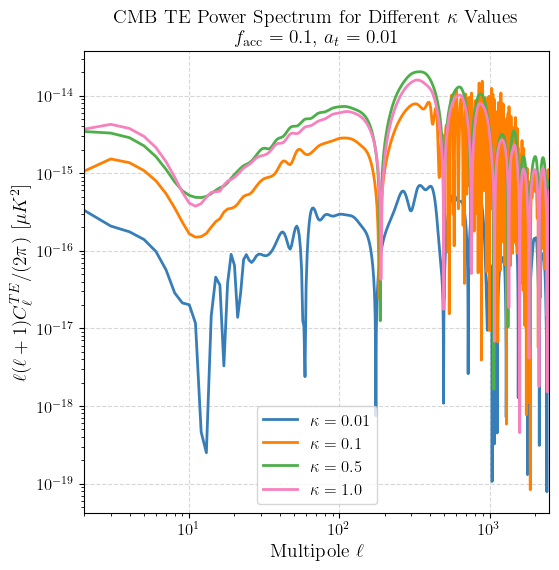

In [ ]:
### Plot TE spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for kappa in kappa_list:
    ll_acc = ll['AccDM', kappa]
    clTE_acc = ll_acc*(1+ll_acc)*clTE['AccDM', kappa]/(2*np.pi)
    ll_mon = ll['DCDM->DR', kappa]
    clTE_mon = clTE['DCDM->DR', kappa]/(2*np.pi)*ll_mon*(1+ll_mon)
    
    ax.plot(ll_acc, np.abs(clTE_acc-clTE_mon), label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('log')
# ax.set_ylim(0.8, 1.5)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{TE}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB TE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\k'
<>:19: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_201756/3231665288.py:19: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title(f'CMB EE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)


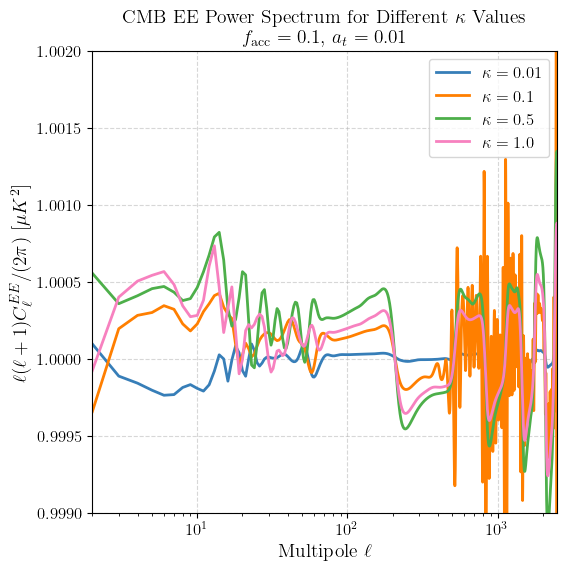

In [ ]:
### Plot TT spectrum
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for kappa in kappa_list:
    ll_acc = ll['AccDM', kappa]
    clEE_acc = ll_acc*(1+ll_acc)*clEE['AccDM', kappa]/(2*np.pi)
    ll_mon = ll['DCDM->DR', kappa]
    clEE_mon = clEE['DCDM->DR', kappa]/(2*np.pi)*ll_mon*(1+ll_mon)
    
    ax.plot(ll_acc, clEE_acc/clEE_mon, label=r'$\kappa = {}$'.format(kappa), linewidth=2, ls = '-', color=colors_colorblind[kappa_list.index(kappa)])
    
ax.set_xscale('log')
ax.set_xlim(2, 2500)
ax.set_yscale('linear')
ax.set_ylim(0.999, 1.002)
# ax.set_ylim(1e-3, 1e4)
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{EE}/(2\pi)$ [$\mu K^2$]')
ax.set_title(f'CMB EE Power Spectrum for Different $\kappa$ Values\n$f_{{\\mathrm{{acc}}}} = {f_acc}$, $a_t = {a_t}$', fontsize=14)
ax.legend()
ax.grid(ls='--', alpha=0.5)
plt.show()